# 🧠 Capstone Project: Sales Data Analysis Using Python, NumPy, Pandas, Matplotlib & Seaborn


### 🎯 Objective
Analyze synthetic sales data to understand performance trends across products, regions, and time using Python data analysis libraries.



## 📂 Dataset Overview (`sales_data.csv`)

**Columns:**
- `Date`: Date of transaction (2023)
- `Region`: Sales region (North, South, East, West)
- `Product`: Product name
- `Units_Sold`: Quantity of units sold
- `Unit_Price`: Price per unit
- `Revenue`: Calculated as `Units_Sold * Unit_Price`


## 🧩 Section 1 — Setup and Data Loading

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the sales transaction dataset into a Pandas DataFrame for exploratory analysis.
df = pd.read_csv("sales_data.csv")

# Preview the dataset to understand the available sales, product, and regional attributes.
df.head()


,Date,Region,Product,Units_Sold,Unit_Price,Revenue
0,2023-04-13,East,Laptop,18,761,13698
1,2023-12-15,South,Headphones,25,648,16200
2,2023-09-28,North,Tablet,12,1475,17700
3,2023-04-17,West,Tablet,15,411,6165
4,2023-03-13,West,Laptop,26,972,25272


In [ ]:

# Assess data quality by validating data types and identifying missing values before analysis.
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        500 non-null    object
 1   Region      500 non-null    object
 2   Product     500 non-null    object
 3   Units_Sold  500 non-null    int64 
 4   Unit_Price  500 non-null    int64 
 5   Revenue     500 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 23.6+ KB


Date          0
Region        0
Product       0
Units_Sold    0
Unit_Price    0
Revenue       0
dtype: int64

In [ ]:

# Generate descriptive statistics to understand the distribution of key sales metrics.
df.describe()


,Units_Sold,Unit_Price,Revenue
count,500.000000,500.000000,500.000000
mean,25.158000,1063.988000,26271.340000
std,13.812698,522.465521,20152.656004
min,1.000000,101.000000,240.000000
25%,13.000000,623.750000,10497.000000
50%,25.000000,1073.500000,20987.000000
75%,37.000000,1475.250000,38700.750000
max,49.000000,1980.000000,92928.000000


## 🔢 Section 2 — NumPy Analysis

In [ ]:

# Extract revenue values into a NumPy array for statistical analysis.
revenue_array = df['Revenue'].values

# Calculate key revenue statistics to evaluate overall sales performance.
print("Mean Revenue:", np.mean(revenue_array))
print("Median Revenue:", np.median(revenue_array))
print("Max Revenue:", np.max(revenue_array))
print("Min Revenue:", np.min(revenue_array))
print("Standard Deviation:", np.std(revenue_array))


Mean Revenue: 26271.34
Median Revenue: 20987.0
Max Revenue: 92928
Min Revenue: 240
Standard Deviation: 20132.493261799442


In [ ]:

# Estimate post-tax revenue by applying a 10% tax rate to every transaction.
revenue_with_tax = revenue_array * 1.10
revenue_with_tax[:10]


array([15067.8, 17820. , 19470. ,  6781.5, 27799.2, 53308.2, 87417. ,
       29257.8, 94972.9, 30060.8])

In [ ]:

# Identify high-value sales transactions exceeding the defined revenue threshold.
high_revenue = revenue_array[revenue_array > 50000]
high_revenue[:10]


array([79470, 86339, 76104, 73575, 63342, 66263, 58266, 67081, 83700,
       51660])

## 🧾 Section 3 — Business Performance Analysis

In [ ]:
# Analyze total revenue by region to identify the highest-performing sales markets.
toatl_revenue_per_region=df.groupby('Region')['Revenue'].sum()
print(toatl_revenue_per_region)

Region
East     3289533
North    3848855
South    2794663
West     3202619
Name: Revenue, dtype: int64


In [ ]:
#Determine the best-selling product based on total units sold.

mostSoldProduct=df.groupby('Product')['Units_Sold'].sum().idxmax()
mostSoldProductCount=df.groupby('Product')['Units_Sold'].sum().max()
print("Product with the most units sold is ",unitsPerProduct," and count ",mostSoldProductCount)

Product with the most units sold is  Laptop  and count  2858


In [ ]:
# Compare the average selling price across products to evaluate pricing trends.
avgUnitPriceProduct=df.groupby('Product')['Unit_Price'].mean()
print(avgUnitPriceProduct)

Product
Camera        1121.463918
Headphones     987.820225
Laptop        1040.927273
Smartphone    1071.113208
Tablet        1094.448980
Name: Unit_Price, dtype: float64


In [ ]:
# Perform monthly sales trend analysis to identify the highest revenue-generating month.
df['Date'] = pd.to_datetime(df['Date'])
df['Month']=df['Date'].dt.month
monthMap = {
    1: 'Jan',
    2: 'Feb',
    3: 'Mar',
    4: 'Apr',
    5: 'May',
    6: 'Jun',
    7: 'Jul',
    8: 'Aug',
    9: 'Sep',
    10: 'Oct',
    11: 'Nov',
    12: 'Dec'
}
df['Month_Name'] = df['Month'].map(monthMap)

monthly_revenue = df.groupby('Month')['Revenue'].sum()
print(monthly_revenue)

top_month = monthly_revenue.idxmax()
top_value = monthly_revenue.max()


monthly_revenue = df.groupby('Month_Name')['Revenue'].sum()

print(f"Month with highest revenue: {top_month} ({top_value})")


Month
1      851424
2     1214874
3      433659
4     1122903
5     1602193
6      899801
7      991171
8     1380537
9     1262918
10     995021
11    1279793
12    1101376
Name: Revenue, dtype: int64
Month with highest revenue: 5 (1602193)


In [ ]:
#Analyze product sales performance across regions using a pivot table.
pivot_units = pd.pivot_table(
    df,
    values='Units_Sold',
    index='Region',
    columns='Product',
    aggfunc='sum',
    fill_value=0
)

print(pivot_units)

Product  Camera  Headphones  Laptop  Smartphone  Tablet
Region                                                 
East        730         434     854         781     227
North       682         617     900         648     866
South       585         690     523         584     444
West        370         534     581         780     749


## 📊 Section 4 — Data Visualization

Month
1      851424
2     1214874
3      433659
4     1122903
5     1602193
6      899801
7      991171
8     1380537
9     1262918
10     995021
11    1279793
12    1101376
Name: Revenue, dtype: int64
Index(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct',
       'Nov', 'Dec'],
      dtype='object', name='Month')


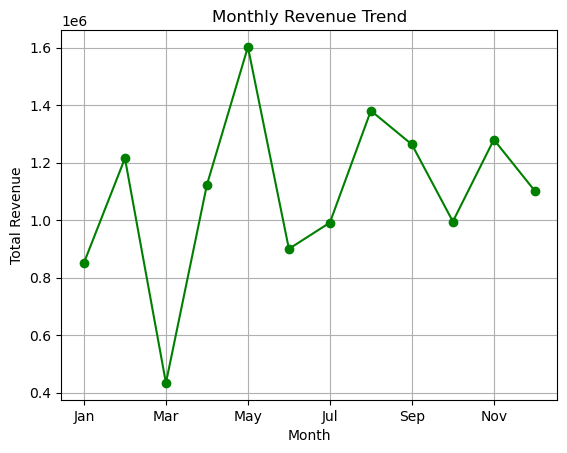

In [ ]:

# Visualize monthly revenue trends to monitor sales performance throughout the year.
df['Date']=pd.to_datetime(df['Date'])
df['Month']=df['Date'].dt.month
monthly_revenue=df.groupby('Month')['Revenue'].sum()
print(monthly_revenue)
monthMap = {
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
    7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
}
monthly_revenue.index=monthly_revenue.index.map(monthMap)
print(monthly_revenue.index)
monthly_revenue.plot(kind='line', marker='o', color='green')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.grid(True)
plt.show()

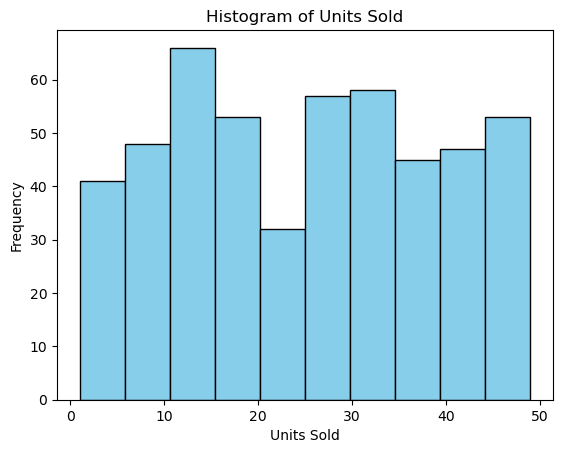

In [ ]:
# Analyze the distribution of units sold across all transactions.
plt.hist(df['Units_Sold'], bins=10, color='skyblue', edgecolor='black')
plt.title("Histogram of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()

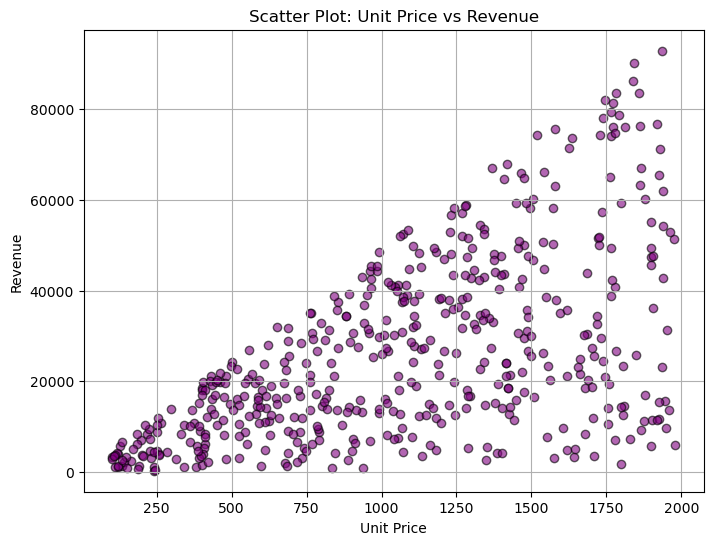

In [ ]:
# Examine the relationship between product pricing and revenue generation.
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df['Unit_Price'], df['Revenue'], color='purple', alpha=0.6, edgecolors='black')
plt.title("Scatter Plot: Unit Price vs Revenue")
plt.xlabel("Unit Price")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()


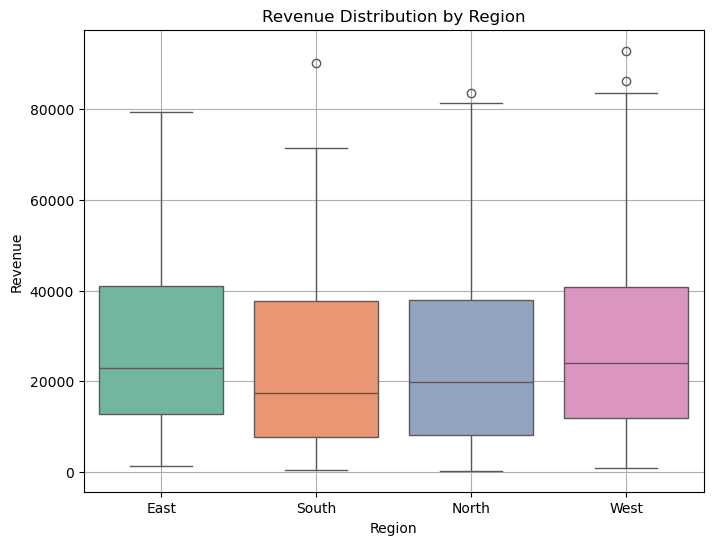

In [ ]:
# Compare revenue distribution across regions to identify performance variability and potential outliers.
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(x='Region', y='Revenue', data=df, hue='Region', palette='Set2', legend=False)

plt.title("Revenue Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()


## 🎨 Section 5 — Advanced Visualization

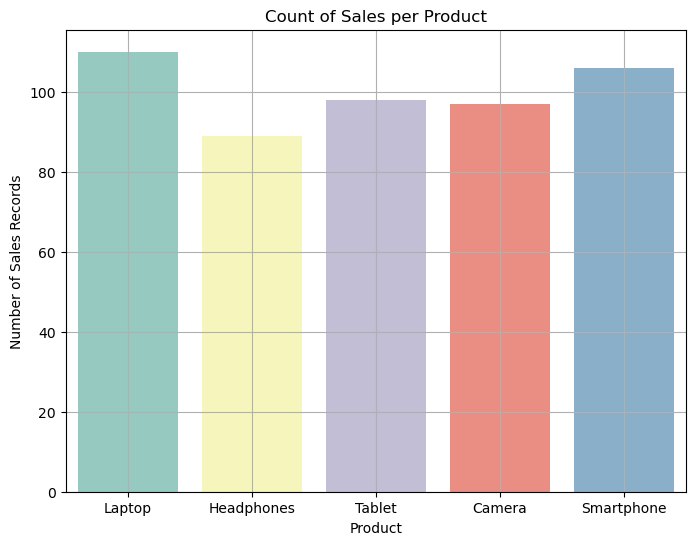

In [ ]:
# Compare transaction volumes across products to identify the most frequently sold items.
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.countplot(x='Product', data=df, hue='Product', palette='Set3', legend=False)

plt.title("Count of Sales per Product")
plt.xlabel("Product")
plt.ylabel("Number of Sales Records")
plt.grid(True)
plt.show()


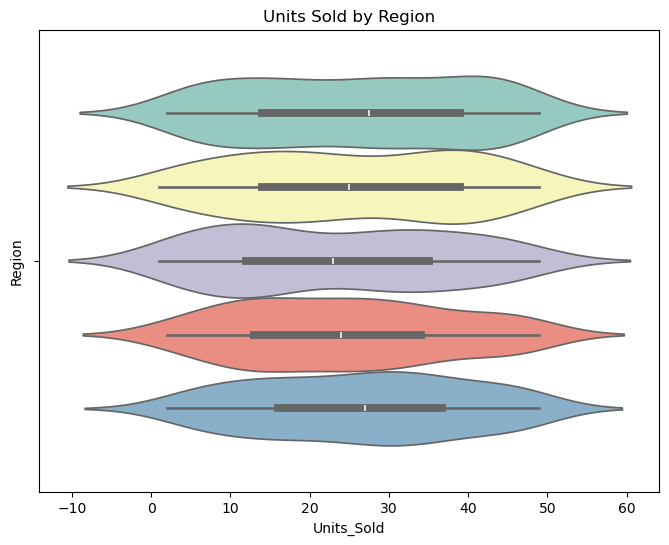

In [ ]:
# Analyze the distribution of units sold across regions to understand sales variability.
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.violinplot(x='Units_Sold', data=df, hue='Product', palette='Set3', legend=False)

plt.title("Units Sold by Region")
plt.xlabel("Units_Sold")
plt.ylabel("Region")
plt.show()

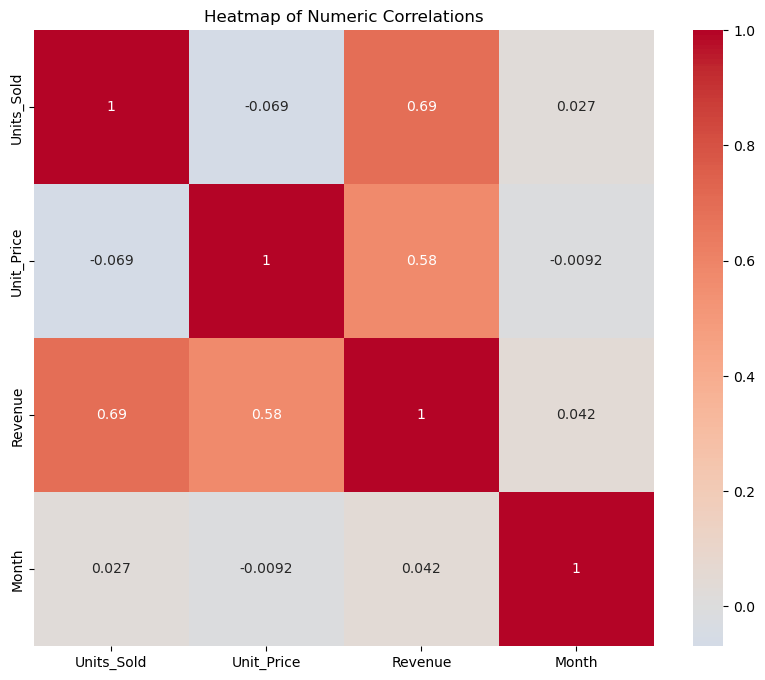

In [ ]:
# Evaluate correlations among sales metrics to identify significant business relationships.
import seaborn as sns
import matplotlib.pyplot as plt


corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Heatmap of Numeric Correlations")
plt.show()


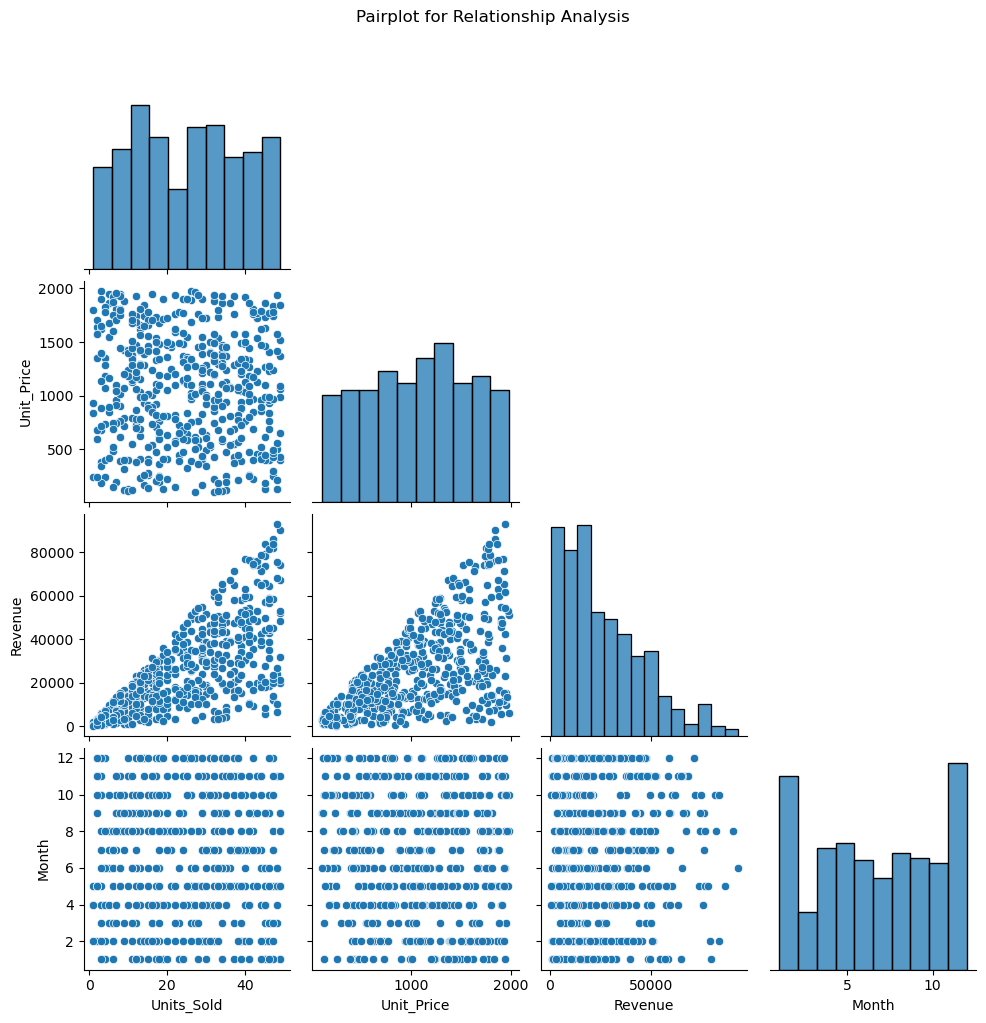

In [ ]:
# Explore relationships among key numerical variables to identify sales trends and potential patterns.
import seaborn as sns
import matplotlib.pyplot as plt


numeric_cols = ['Units_Sold', 'Unit_Price', 'Revenue', 'Month']


sns.pairplot(df[numeric_cols], diag_kind='hist', corner=True)
plt.suptitle("Pairplot for Relationship Analysis", y=1.02)
plt.show()
